In [1]:

import torch
import scanpy as sc
import numpy as np
import os
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
torch.tensor(0).to('cuda')

tensor(0, device='cuda:0')

In [2]:
merged_data=sc.read_h5ad('./mouse_human_brain.h5ad')


In [3]:
#############################################optional#############################################
sc.pp.highly_variable_genes(merged_data, n_top_genes=3000)
merged_data = merged_data[:, merged_data.var['highly_variable']]

#############################################optional#############################################
sn_data = merged_data[merged_data.obs['species']=='Human']
st_data = merged_data[merged_data.obs['species']=='Mouse']

sc.tl.pca(sn_data, n_comps=500)

pca_weights = sn_data.varm['PCs']  # numpy array (n_genes, n_comps)

st_matrix = torch.tensor(st_data.X.toarray()).float()  
pca_weights_torch = torch.tensor(np.copy(pca_weights)).float()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
st_matrix = st_matrix.to(device)
pca_weights_torch = pca_weights_torch.to(device)

st_pca = torch.matmul(st_matrix, pca_weights_torch).cpu().numpy().astype(np.float64)
sn_data.obsm['X_pca'] = sn_data.obsm['X_pca'].astype(np.float64)

st_pca_corr = []
for i in range(st_pca.shape[1]):
    pcs = (st_pca[:,i]-st_pca[:,i].mean())/st_pca[:,i].std()*sn_data.obsm['X_pca'][:,i].std()+sn_data.obsm['X_pca'][:,i].mean()
    st_pca_corr.append(pcs)
st_data.obsm['X_pca'] = np.array(st_pca_corr).T

st_data_pca = sc.AnnData(X=st_data.obsm['X_pca'],obs=st_data.obs,obsm=st_data.obsm)
sn_data_pca = sc.AnnData(X=sn_data.obsm['X_pca'],obs=sn_data.obs,obsm=sn_data.obsm)

merged_data = sc.concat([sn_data_pca,st_data_pca])

In [4]:
import os
os.chdir('/cluster/home/sunyk/deeplearning/sun_algo/rmge')

from model import RMGE 
from integration import HomologyMapper,CrossSpeciesAligner


species_list = ['Mouse', 'Human']
rmge_list={}
weight={}

for sp in species_list:
    sub_merged_data1,sub_merged_data2 = merged_data[merged_data.obs['species']==sp], merged_data[merged_data.obs['species']!=sp]
    sub_merged_data2.X = sub_merged_data2.X*(sub_merged_data1.X.mean(axis=0)/(sub_merged_data2.X.mean(axis=0)+1e-50))
    rmge = RMGE(sub_merged_data1,sub_merged_data2, device='cuda',class_columns = 'SubClass',kl_weight=0)
    train_losses, train_accuracies = rmge.train(epochs=500)
    rmge_list[sp]=rmge
    weight[sp] = rmge_list[sp].model.fc.weight.cpu().detach().numpy()




Epoch 0/500, Loss: 9.70179557800293, Accuracy: 0.5272727272727272
Epoch 100/500, Loss: 2.2929506301879883, Accuracy: 0.9647727272727272
Epoch 200/500, Loss: 2.29071044921875, Accuracy: 0.965625
Epoch 300/500, Loss: 2.2962117195129395, Accuracy: 0.9633522727272728
Epoch 400/500, Loss: 2.2667338848114014, Accuracy: 0.9661931818181818
Epoch 0/500, Loss: 9.70284652709961, Accuracy: 0.20539772727272726
Epoch 100/500, Loss: 3.6584019660949707, Accuracy: 0.9911931818181818
Epoch 200/500, Loss: 3.6227810382843018, Accuracy: 0.9914772727272727
Epoch 300/500, Loss: 3.6690468788146973, Accuracy: 0.990909090909091
Epoch 400/500, Loss: 3.6399898529052734, Accuracy: 0.9911931818181818


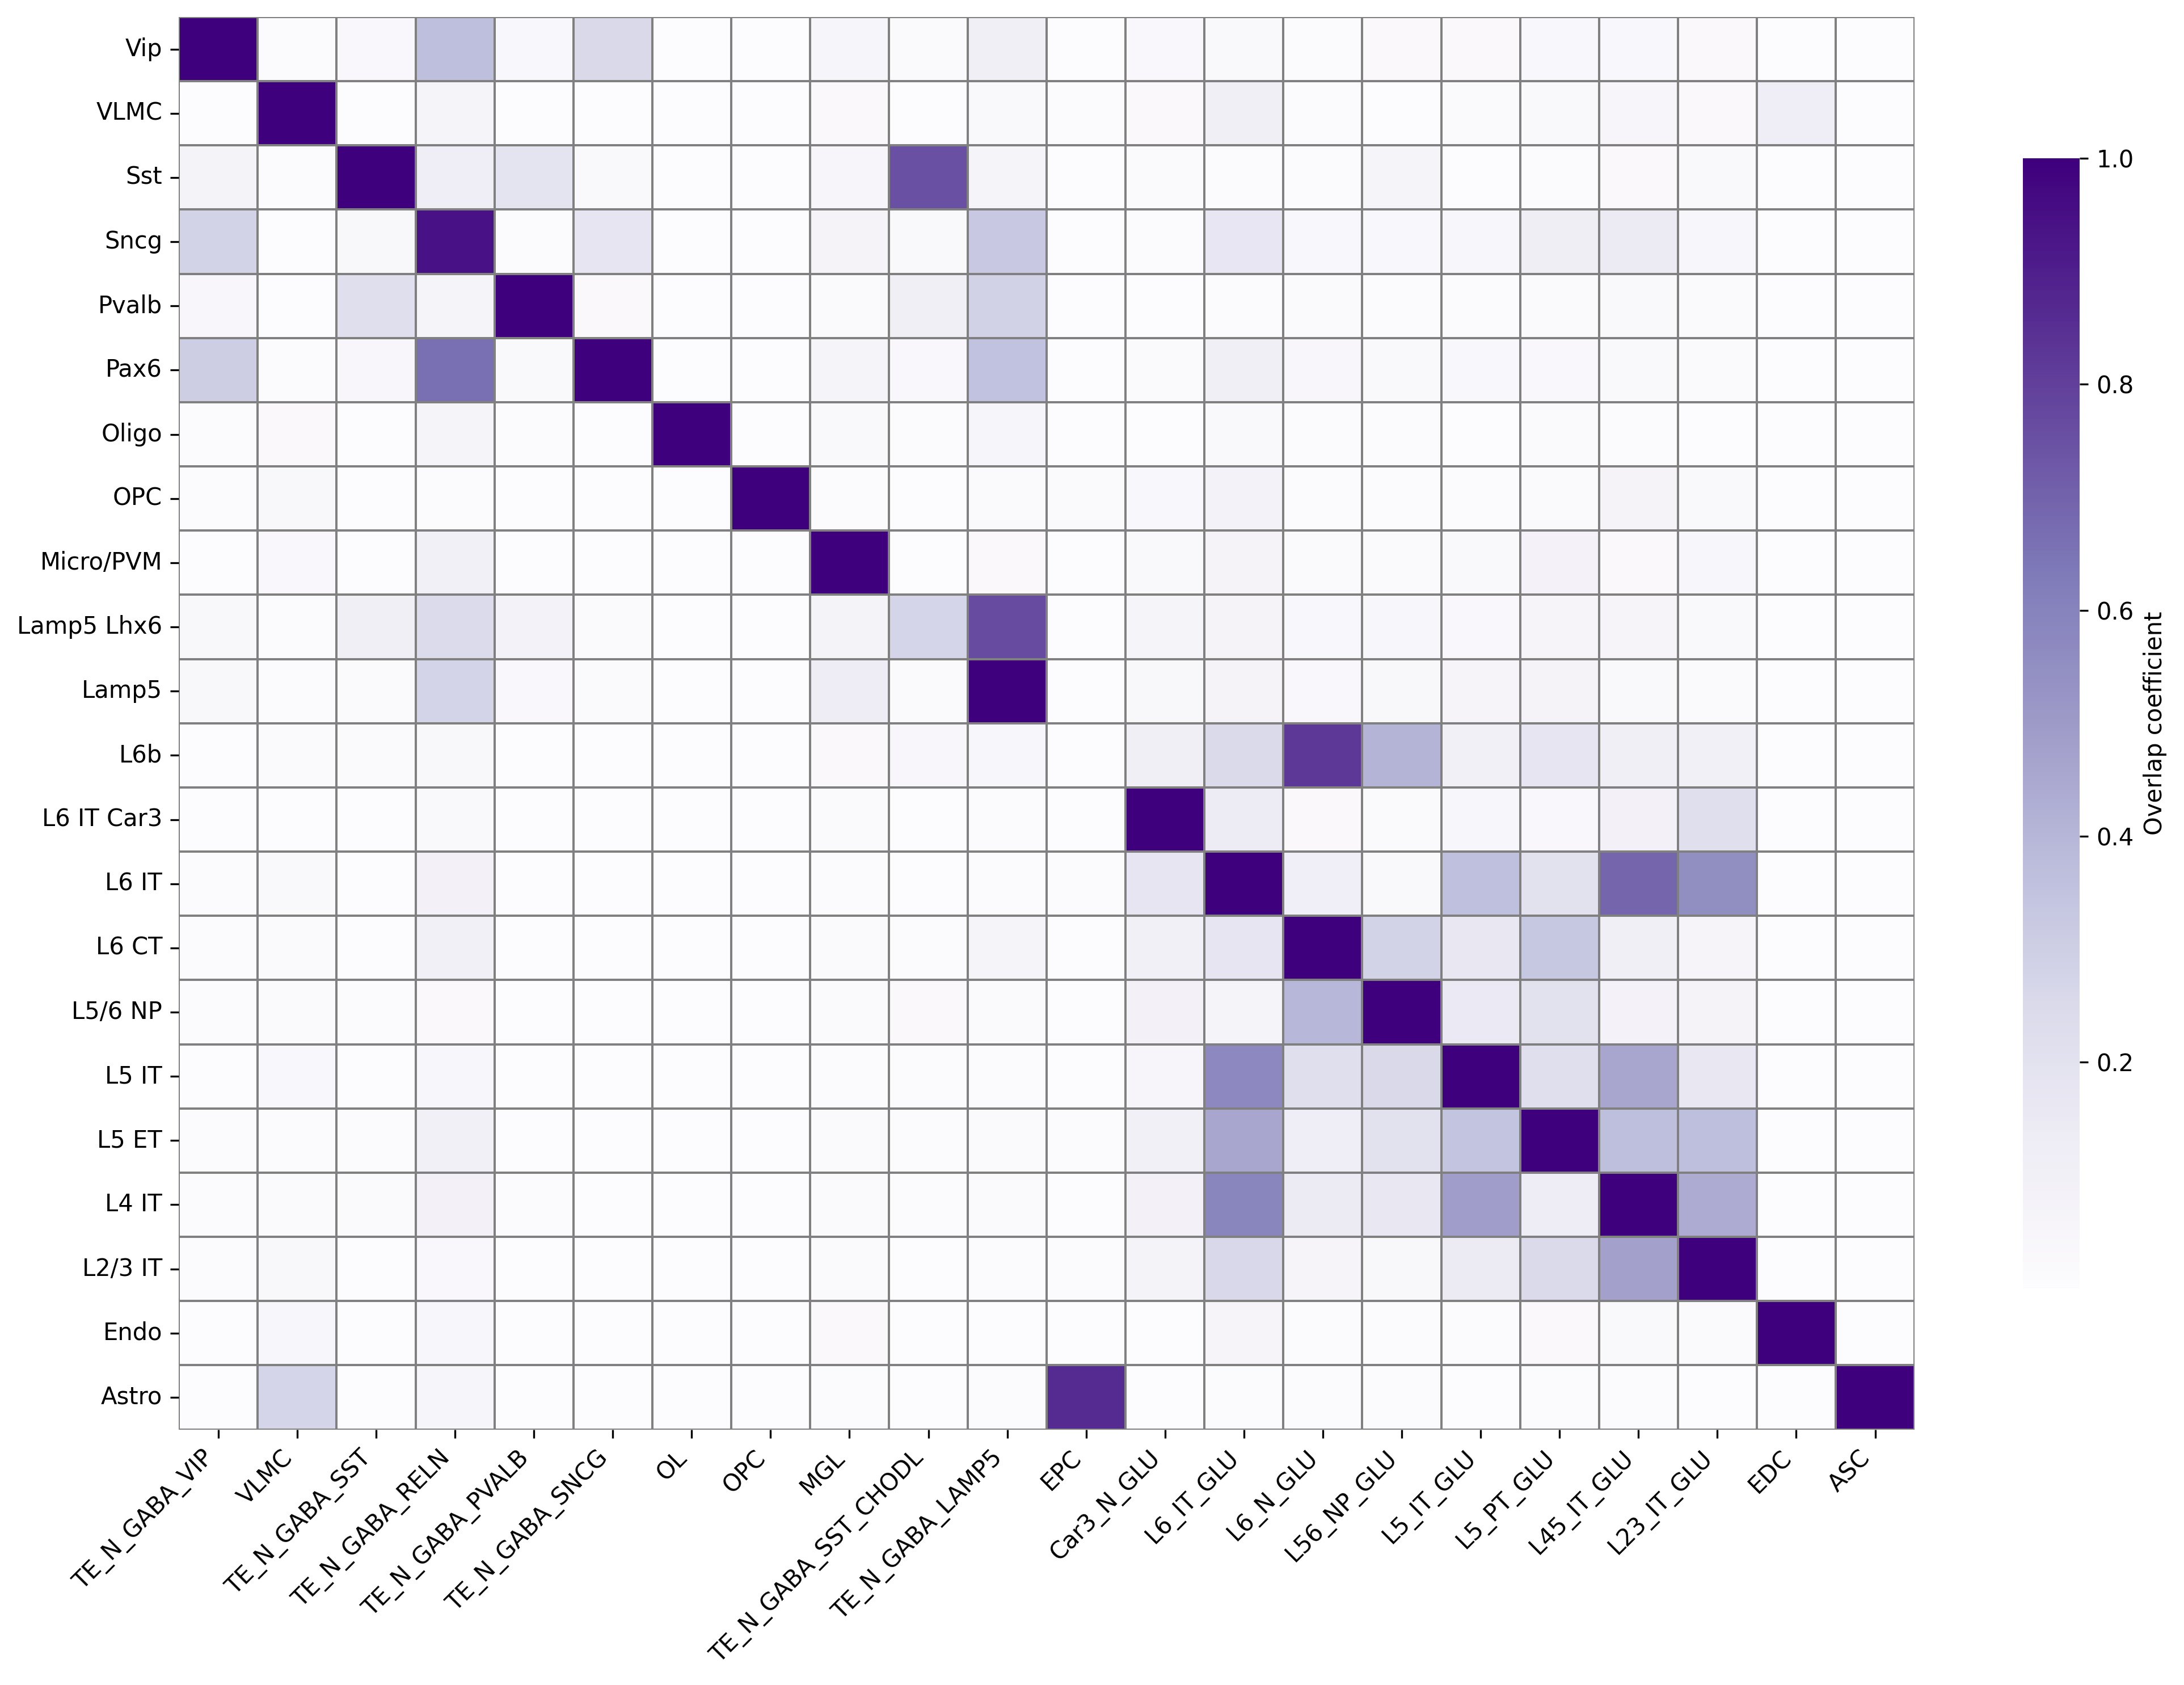

In [5]:

mapper = HomologyMapper(
    merged_data=merged_data,
    rmge_list=rmge_list,
    species_pair=['Human', 'Mouse'],
    cell_type_col='SubClass',
    overlap_threshold=0.6,
    adjusted_diff_threshold=0.5,
    device='cuda'
)

# 执行同源性映射
merged_data_homologous = mapper.compute_homology()
mapper.plot_consensus_heatmap()

In [7]:
import os
os.chdir('/cluster/home/sunyk/deeplearning/sun_algo/rmge')

import torch
import scanpy as sc
import numpy as np

import pandas as pd
import scipy.cluster.hierarchy as sch
from model import RMGE 
import matplotlib.pyplot as plt
import seaborn as sns

species_list = ['Human','Mouse']

rmge_list={}
weight={}

for sp in species_list:
    rmge = RMGE(merged_data_homologous[merged_data_homologous.obs['species']==sp], merged_data_homologous[merged_data_homologous.obs['species']!=sp], device='cuda',class_columns = 'predict',kl_weight=0,dropout_rate=0.8)
    train_losses, train_accuracies = rmge.train(epochs=500)
    predict_class_names = rmge.evaluate()
    rmge_list[sp]=rmge
    weight[sp] = rmge_list[sp].model.fc.weight.cpu().detach().numpy()





Epoch 0/500, Loss: 9.657877922058105, Accuracy: 0.1878125
Epoch 100/500, Loss: 3.5205633640289307, Accuracy: 0.990625
Epoch 200/500, Loss: 3.601203680038452, Accuracy: 0.9909375
Epoch 300/500, Loss: 3.580181360244751, Accuracy: 0.9925
Epoch 400/500, Loss: 3.6043574810028076, Accuracy: 0.9925
Validation Accuracy: 0.9862
Epoch 0/500, Loss: 9.74453353881836, Accuracy: 0.459375
Epoch 100/500, Loss: 2.2274787425994873, Accuracy: 0.9667613636363637
Epoch 200/500, Loss: 2.262955665588379, Accuracy: 0.9676136363636364
Epoch 300/500, Loss: 2.2569472789764404, Accuracy: 0.9667613636363637
Epoch 400/500, Loss: 2.2304303646087646, Accuracy: 0.9642045454545455
Validation Accuracy: 0.9386


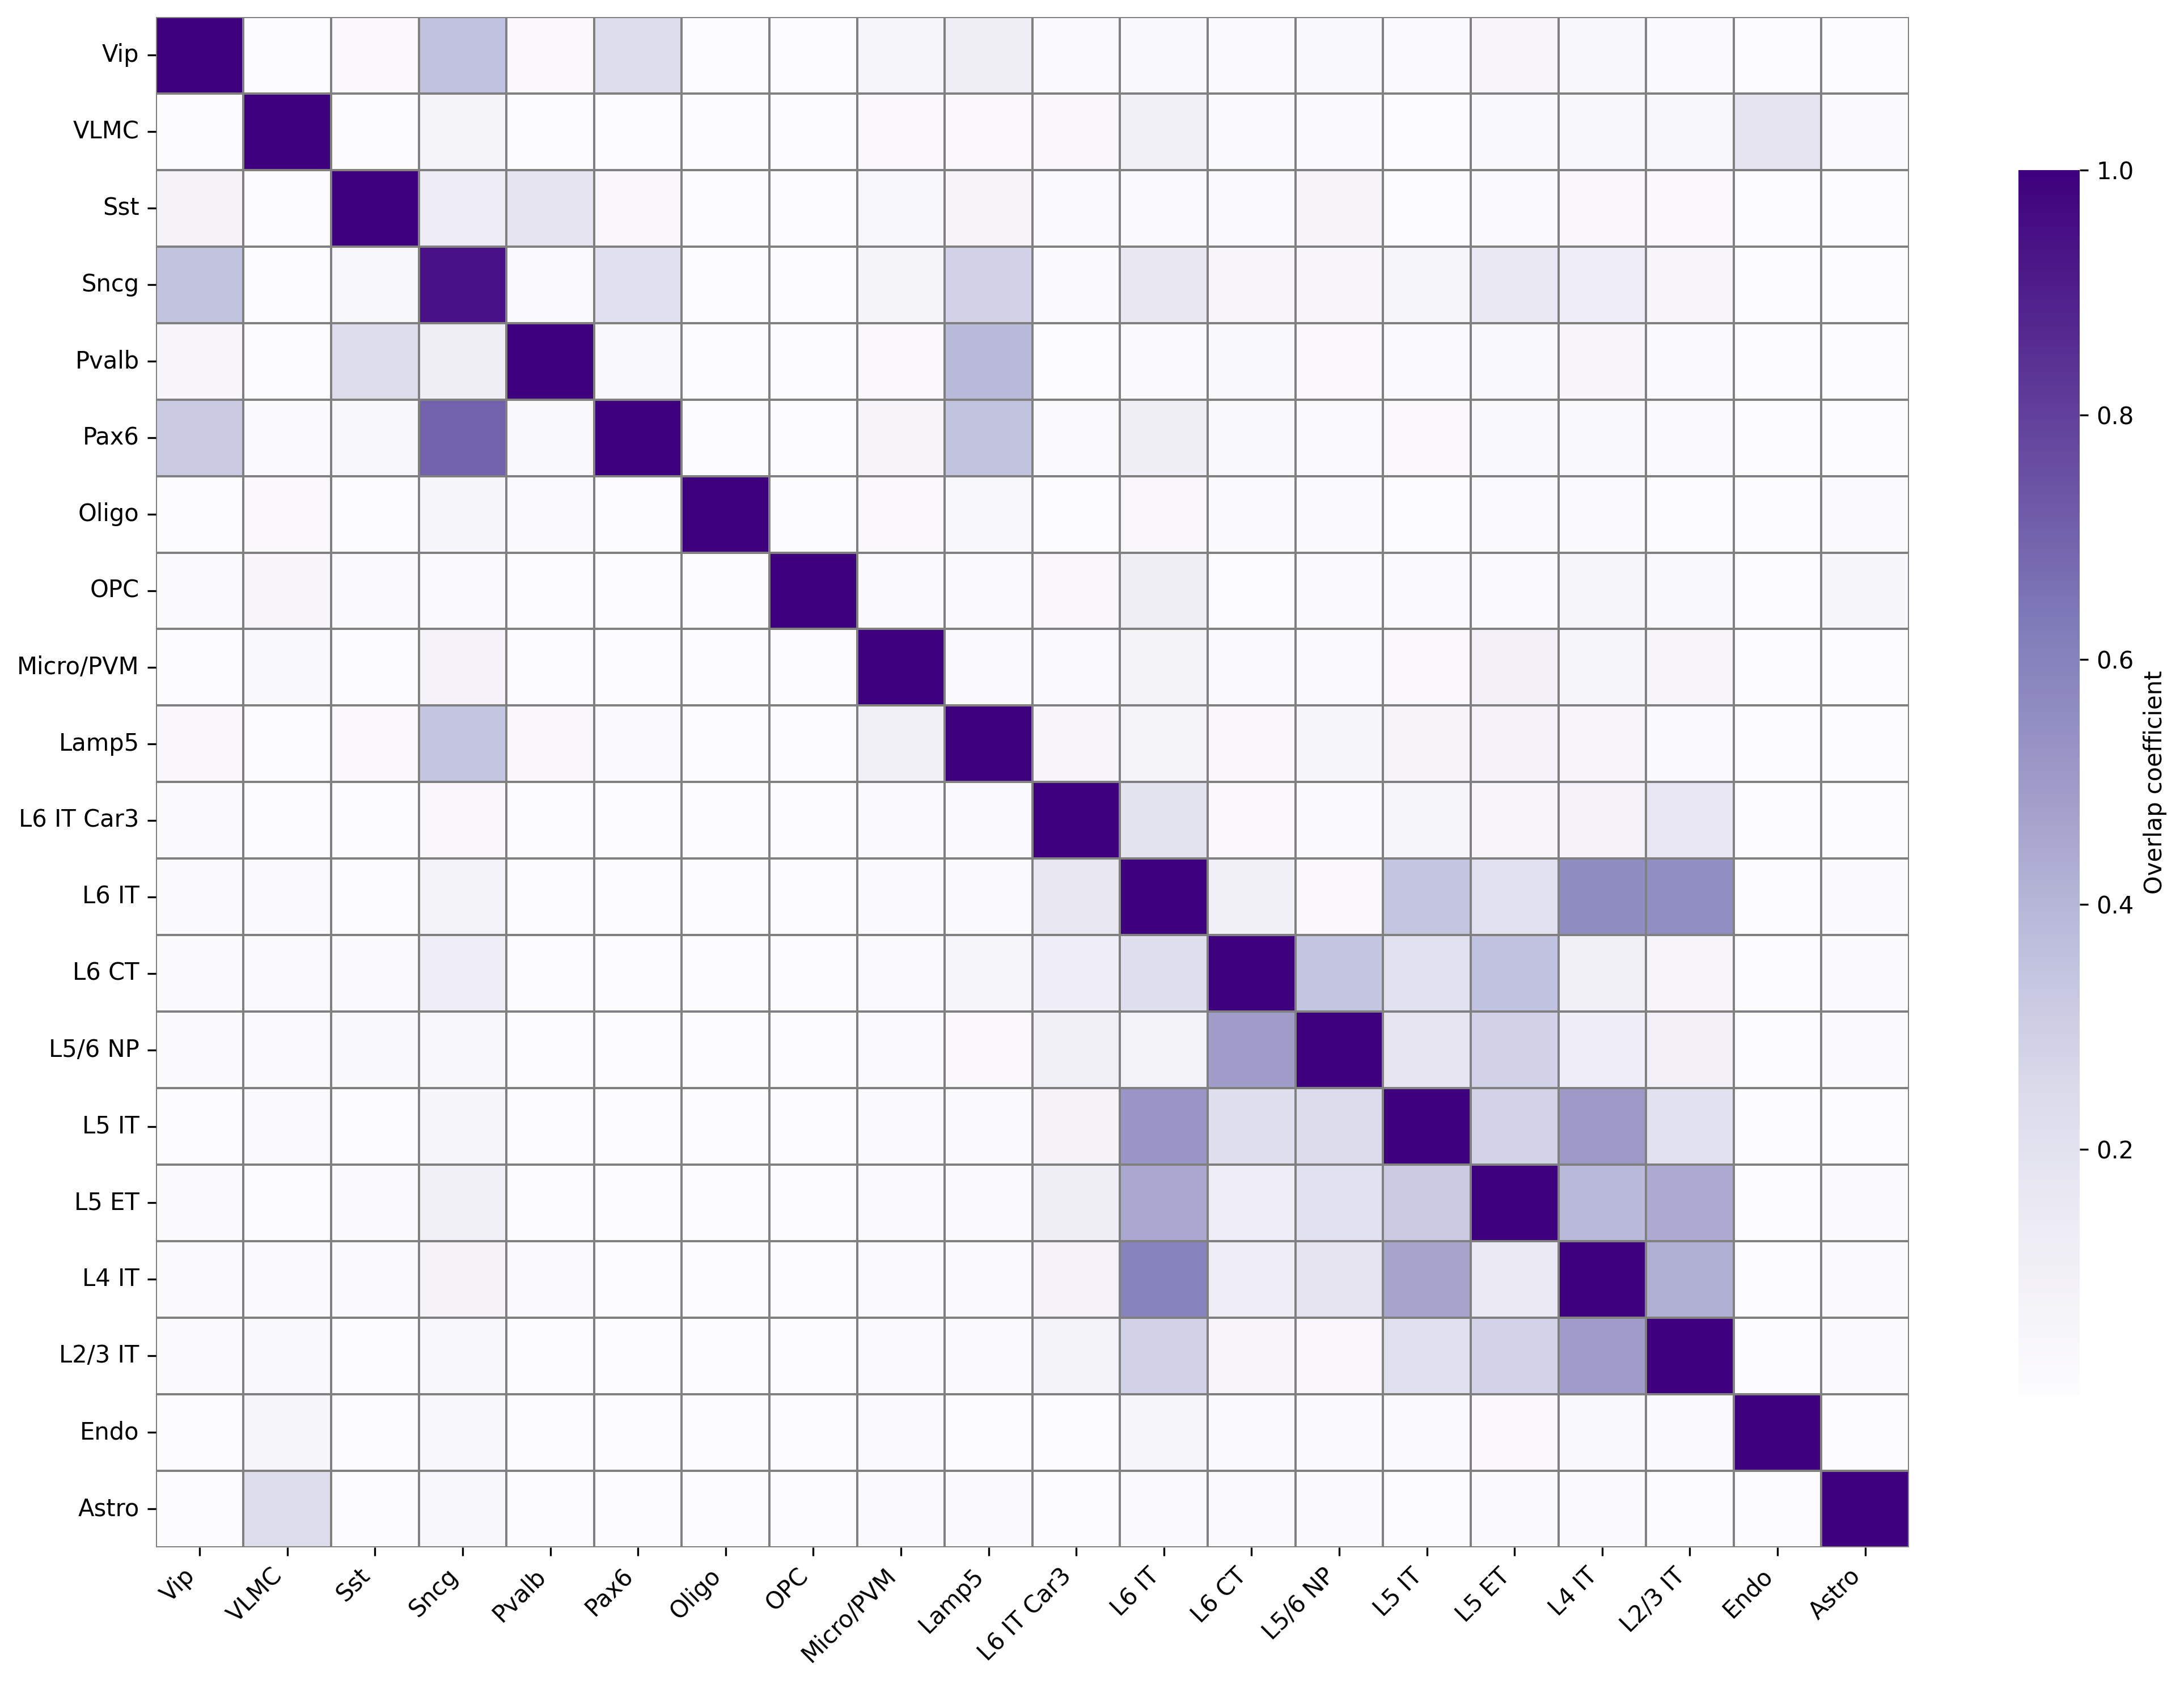

In [8]:

mapper_refined = HomologyMapper(
    merged_data=merged_data_homologous,     
    rmge_list=rmge_list,
    species_pair=['Human', 'Mouse'],       
    cell_type_col='predict',              
    overlap_threshold=0.6,
    device='cuda'
)

merged_homologous_v2 = mapper_refined.compute_homology()
mapper_refined.plot_consensus_heatmap()


Processing subclass: VLMC for species Human
Processing subclass: Astro for species Human
Processing subclass: L6 IT Car3 for species Human
Processing subclass: Oligo for species Human
Processing subclass: Vip for species Human
Processing subclass: Sst for species Human
Processing subclass: Pax6 for species Human
Processing subclass: Sncg for species Human
Processing subclass: Pvalb for species Human
Processing subclass: Lamp5 for species Human
Processing subclass: OPC for species Human
Processing subclass: Micro/PVM for species Human
Processing subclass: Endo for species Human
Processing subclass: L6 CT for species Human
Processing subclass: L6 IT for species Human
Processing subclass: L5 ET for species Human
Processing subclass: L5 IT for species Human
Processing subclass: L5/6 NP for species Human
Processing subclass: L4 IT for species Human
Processing subclass: L2/3 IT for species Human
Processing subclass: Vip for species Mouse
Processing subclass: Sncg for species Mouse
Processing

/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


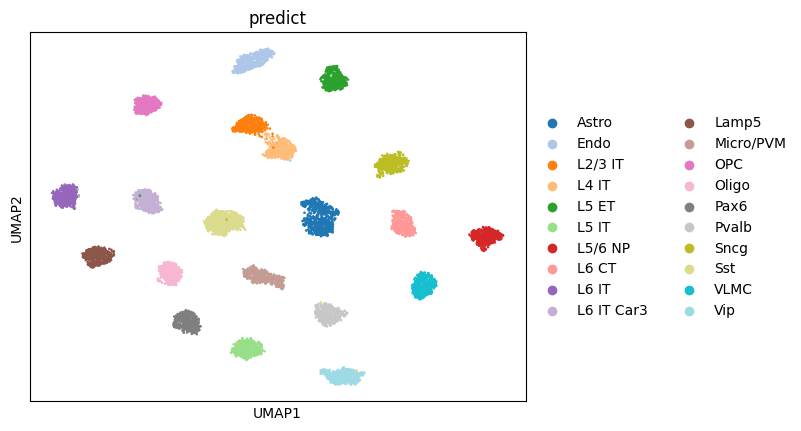

/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


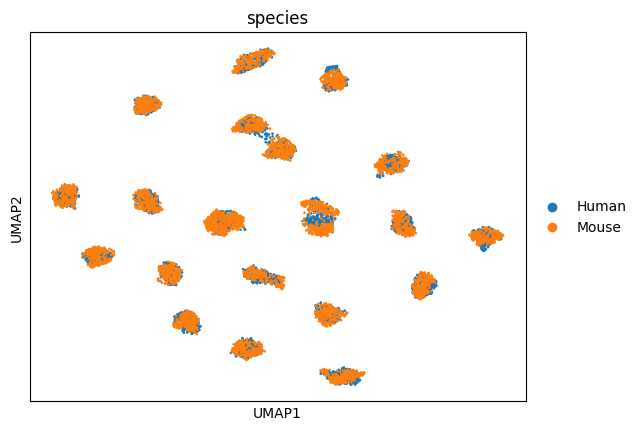

/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


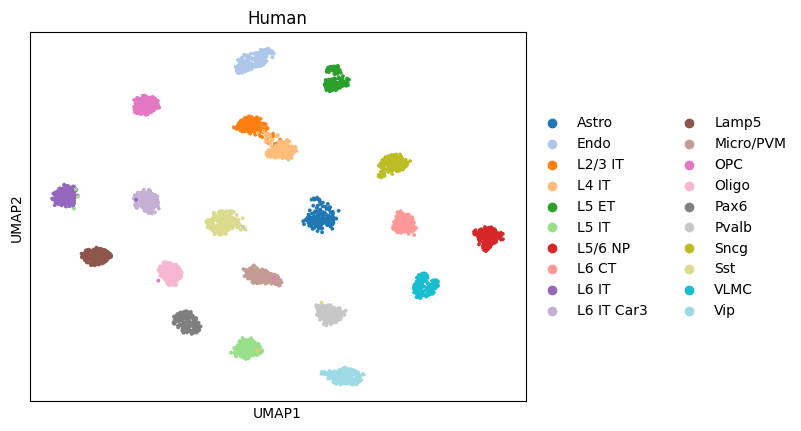

/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


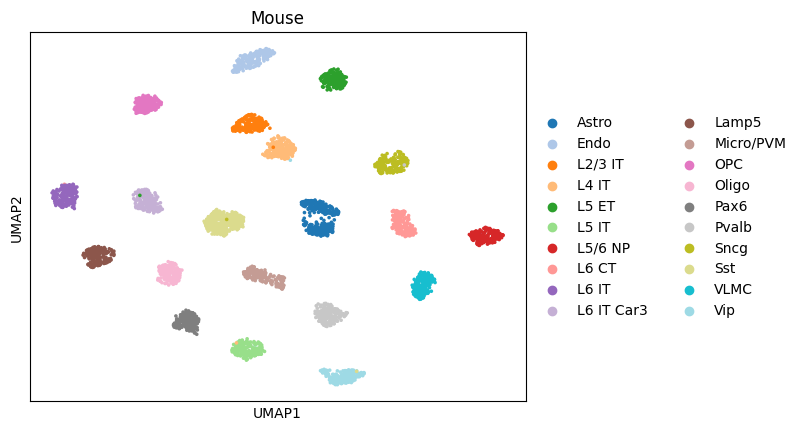

In [9]:


aligner = CrossSpeciesAligner(
    merged_data_homologous=merged_data_homologous,
    rmge_list=rmge_list,
    species_list=['Human', 'Mouse'],
    device='cuda',
    predict_col='predict'
)

combined_data = aligner.align()
aligner.run_umap()